In [109]:
from langgraph.graph import StateGraph,START,END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict,Literal
from pydantic import BaseModel,Field
from dotenv import load_dotenv

In [110]:
load_dotenv()
model = ChatGoogleGenerativeAI(
    model='gemini-3.6-flash'
)

In [ ]:
class SentimentSchema(BaseModel):
    
    sentiment:Literal['positive','nega tive'] = Field(description='sentiment of the review')

In [112]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')
    

In [113]:
structure_model=model.with_structured_output(SentimentSchema)
structure_model2=model.with_structured_output(DiagnosisSchema)

In [114]:
class ReviewState(TypedDict):
    review:str
    sentiment:Literal['positive','negative']
    diagnosis:dict
    response:str

In [115]:
def find_sentiment(state:ReviewState):
    
    prompt = f'for the following the review find out the sentiment \n {state["review"]}'
    sentiment = structure_model.invoke(prompt).sentiment
    
    return {'sentiment':sentiment}

def check_sentiment(state:ReviewState)-> Literal['positive_response','run_diagnosis']:
    if state['sentiment']=='positive':
        return 'positive_response'
    else:
        return 'run_diagnosis'

In [116]:
def positive_response(state:ReviewState):
    prompt =f'''Write a warm thank-you message in response to this review:
    \n\n\"{state['review']}\"\n
    Also, kindly ask the user to leave feedback on our website'''
    
    response=model.invoke(prompt).text
    return {'response':response}

def run_diagnosis(state:ReviewState):
    prompt = f'''Diagnose this negative review:\n\n{state['review']}\n"
    "Return issue_type, tone, and urgency.'''
    
    diagnosis=structure_model2.invoke(prompt)
    
    return {'diagnosis':diagnosis.model_dump()}

def  negative_response(state:ReviewState):
    diagnosis = state['diagnosis']
    prompt =f'''You are a support assistant.
The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
Write an empathetic, helpful resolution message.'''
    response=model.invoke(prompt).text
    return {'response':response}

In [117]:
graph = StateGraph(ReviewState)


graph.add_node('find_sentiment',find_sentiment)
graph.add_node('positive_response',positive_response)
graph.add_node('run_diagnosis',run_diagnosis)
graph.add_node('negative_response',negative_response)



graph.add_edge(START,'find_sentiment')

graph.add_conditional_edges('find_sentiment',check_sentiment)

graph.add_edge('positive_response',END)
graph.add_edge('run_diagnosis','negative_response')
graph.add_edge('negative_response',END)




workflow=graph.compile()


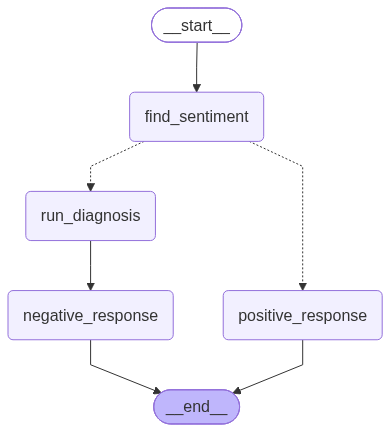

In [118]:
workflow

In [119]:
inital_state={
    'review':'I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.'
}
workflow.invoke(inital_state)


GoogleRateLimitError: Error calling model 'gemini-3.6-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3.6-flash\nPlease retry in 56.54058306s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTier', 'q